<a href="https://colab.research.google.com/github/Anisha2810/Neural-networks-and-deep-learning/blob/main/Time_series_forecasting_using_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2187
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0515
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0162
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.5123e-04
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.4827e-05
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4.2412e-05
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.0127e-05
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.9466e-05
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.7467e-05
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


ValueError: could not broadcast input array from shape (196,) into shape (176,)

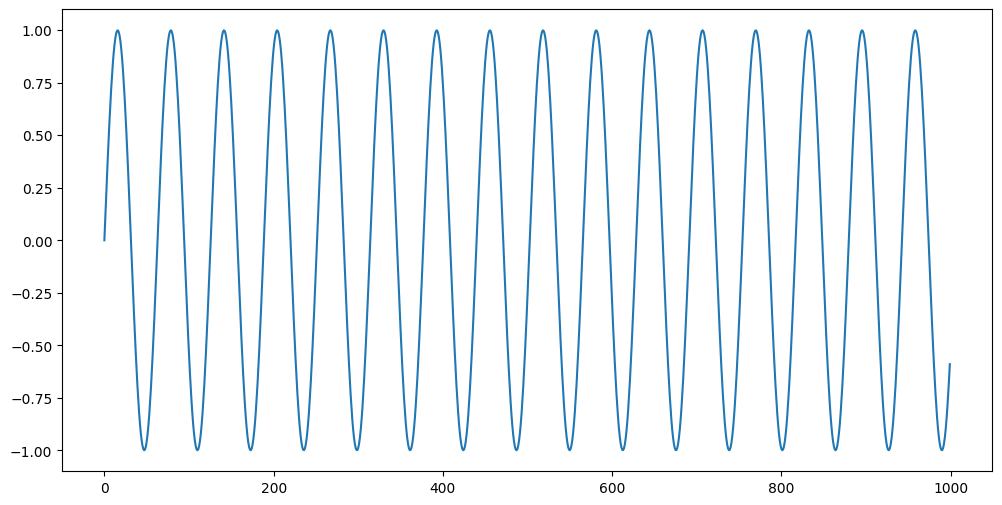

In [1]:
# ==========================================
# Time Series Forecasting using RNN (LSTM)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# ------------------------------
# 1. Generate Time Series Data
# ------------------------------
# (Replace this with your dataset if needed)
time = np.arange(0, 100, 0.1)
series = np.sin(time)

# ------------------------------
# 2. Normalize Data
# ------------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.reshape(-1, 1))

# ------------------------------
# 3. Create Dataset (Sliding Window)
# ------------------------------
def create_dataset(data, time_step=20):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 20
X, y = create_dataset(series_scaled, time_step)

# Reshape to [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# ------------------------------
# 4. Train-Test Split
# ------------------------------
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

# ------------------------------
# 5. Build RNN Model (LSTM)
# ------------------------------
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(time_step, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# ------------------------------
# 6. Train Model
# ------------------------------
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# ------------------------------
# 7. Predictions
# ------------------------------
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform(y_train)

test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform(y_test)

# ------------------------------
# 8. Plot Results
# ------------------------------
plt.figure(figsize=(12,6))

# Original data
plt.plot(series, label='Original Data')

# Train predictions
train_plot = np.empty_like(series)
train_plot[:] = np.nan
train_plot[time_step:len(train_predict)+time_step] = train_predict.flatten()

# Test predictions
test_plot = np.empty_like(series)
test_plot[:] = np.nan
test_plot[len(train_predict)+(time_step*2):len(series)] = test_predict.flatten()

plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')

plt.legend()
plt.title("Time Series Forecasting using RNN (LSTM)")
plt.show()